In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from numpy import random

from InflGame.adaptive.visualization import Shell
import InflGame.utils.general as general
import InflGame.domains.rd as rd


## Resource distribution (beta)

In [2]:
#The resource points
bin_points=np.linspace(.001, .999, 100)





#resource parmaters
resource_parameters=[2,2] #alpha,beta

#Resource distribution
resource_distribution1=rd.resource_distribution_choice(bin_points=bin_points,resource_type='beta',resource_parameters=resource_parameters)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution1)
ax.set_box_aspect(1)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
plt.close()

## Resource distribution (Gaussian sym)

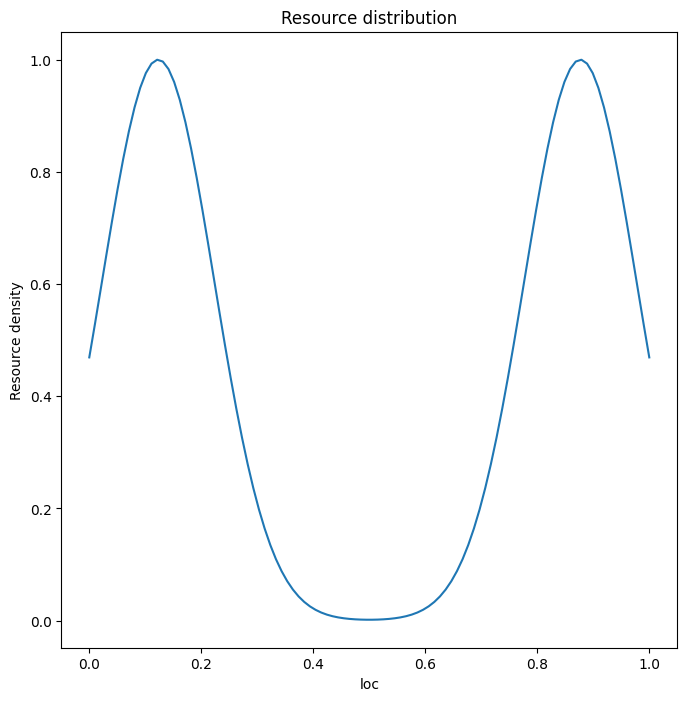

In [3]:
#The resource points
bin_points=np.linspace(.0001, 0.9999, 100)
alpha=0.7537688442211056
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.5-alpha/2,.5+alpha/2],[1,1]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution2=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution2)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.show()


## Resource distribution (Gaussian asym)

In [4]:
#The resource points
bin_points=np.linspace(.001, .999, 100)
 
#Resource parameters
resource_parameters_gaussian_asym=[[.1,.1],[.25,.75],[1,.6]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution3=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian_asym)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution3)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()

## Resource distribution (Noisy)

In [5]:
#The resource points
random.seed(1)
bin_points=np.linspace(.001, .999, 100)

#smoothing kernal (resource parameter)
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth
y=np.abs(random.uniform(low=0,high=1,size=100)+random.normal(loc=.5,scale=.1,size=100))

#Resource distribution
resource_distribution4=smooth(y,box_pts=20)
domain=bin_points

#Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_box_aspect(1)
ax.plot(domain,resource_distribution4)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
#fig.savefig('1d_bimodal_noisy.svg',bbox_inches='tight')
plt.close()

## Resource distribution (uniform)

In [6]:
#The resource points
bin_points=np.linspace(.0001, .9999, 100)
 
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.1,.5],[1,1]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution5=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution5)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()

In [7]:
#The resource points
bin_points=np.linspace(.0001, .9999, 100)

resource_distribution6=np.array([1]*len(bin_points))

#Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_box_aspect(1)
ax.plot(domain,resource_distribution6)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
plt.close()

In [8]:
# bin_points=np.array([0,1])


# resource_distribution7=np.array([10,10])

# #Plot
# fig, ax = plt.subplots(figsize=(12, 8))
# ax.vlines(bin_points, 0, resource_distribution7, colors='b', lw=5)
# ax.set_box_aspect(1)
# ax.scatter(bin_points,resource_distribution7)
# plt.title('Resource distribution')
# plt.xlabel('loc')
# plt.ylabel('Resource density')


## Setup:The enviroment and adapative enviroment

The cell below sets up the outer shell for visualizing the the adapative enviroment. 

In [9]:

domain_type='1d'
resource_distribution=resource_distribution2
mean=np.dot(bin_points,resource_distribution)/np.sum(resource_distribution) #mean of the resource distribution




num_agents=6 #number of agents
#int_agents_pos=general.agent_position_setup(num_agents=num_agents,setup_type='paper_default',domain_type=domain_type,domain_bounds=0)
int_agents_pos=torch.tensor([0.0278, 0.1513, 0.0163, 0.8290, 0.3250, 0.3650]) #initial agent positions

infl_configs={"infl_type":"gaussian"} # influence type of the agents


parameters=general.agent_parameter_setup(num_agents=num_agents,infl_type=infl_configs["infl_type"],setup_type="initial_symmetric_setup",reach=0.21) # parameters impacting agents reach (their std)
#parameters_custom=np.array([[.1,.2,.3,...]]) #needs to be length num_players


time_steps=20000# number steps for the adaptive dynamics


vis=Shell(num_agents=num_agents,agents_pos=int_agents_pos,parameters=parameters,resource_distribution=resource_distribution,bin_points=bin_points, 
infl_configs = infl_configs, learning_rate_type= 'cosine_annealing', learning_rate= [.001, .001, 500], time_steps=time_steps,
fp= 0, infl_cshift= False, cshift = 0, infl_fshift= False, Q = None,
domain_type = '1d', domain_bounds = [0, 1], resource_type = 'na', domain_refinement = 10,
tolerance = 10**-20, tolerated_agents = None,ignore_zero_infl= True)


vis.setup_adaptive_env()
vis.field.gradient_ascent()
og_pos_matrix=vis.field.pos_matrix
og_grad_matrix=vis.field.grad_matrix
vis.agents_pos=int_agents_pos.clone()
vis.field.agents_pos=int_agents_pos.clone()

        

#(0.158184517)


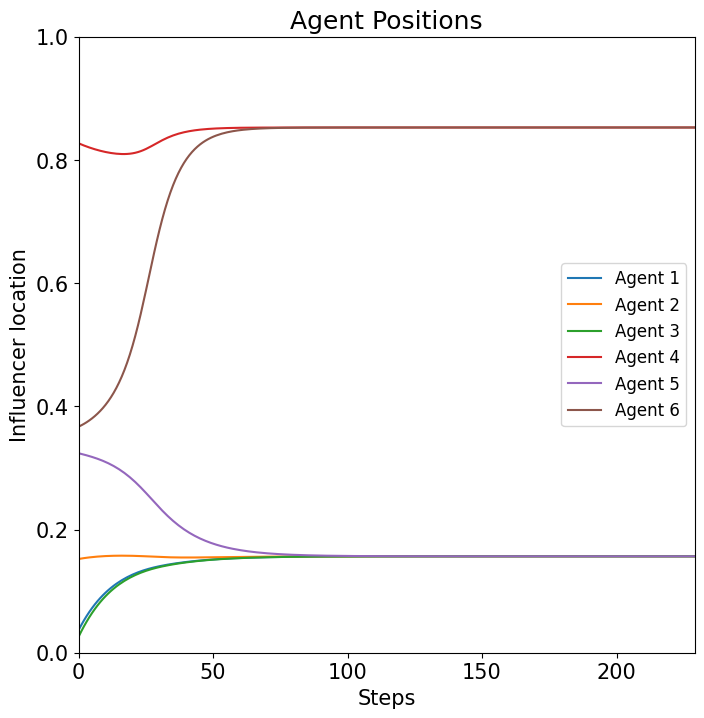

In [10]:
vis.pos_plot()

In [11]:
torch.round(vis.field.pos_matrix[-1],decimals=4)

tensor([0.1565, 0.1565, 0.1565, 0.8527, 0.1565, 0.8527])

In [12]:
resource_distribution_type="multi_modal_gaussian_distribution_1D"
alpha_current=.5
alpha_st=0
alpha_end = 1
varying_parameter_type='mean'
fixed_parameters_lst=[resource_parameters_gaussian[0],resource_parameters_gaussian[2]]
num_points=200


resource_parameters,alpha=general.resource_parameter_setup(resource_distribution_type=resource_distribution_type,varying_parameter_type=varying_parameter_type,alpha_st=alpha_st, alpha_end=alpha_end, fixed_parameters_lst=fixed_parameters_lst,alpha_num_points=num_points)


In [13]:
from InflGame.adaptive.bifurcation_analysis import BifurcationEnv

In [14]:
bif_field=BifurcationEnv(vis.num_agents,vis.agents_pos,vis.parameters,vis.resource_distribution,vis.bin_points,
              vis.infl_configs,vis.learning_rate_type,vis.learning_rate,vis.time_steps,fp= 0, infl_cshift= False, cshift = 0, infl_fshift= False, Q = None,
              domain_type = '1d', domain_bounds = [0, 1], resource_type = 'na', domain_refinement = 10,
              tolerance = 10**-20, tolerated_agents = None,ignore_zero_infl= True)
bif_field.setup_adaptive_env()

In [15]:
import hickle as hkl
"""
test=bif_field.find_second_order_bifs(bin_points=bin_points,
                                      fixed_parameters_lst=fixed_parameters_lst,
                                      resource_distribution_type=resource_distribution_type,
                                      alpha_st=alpha_st,
                                      alpha_end=alpha_end,
                                      num_points=num_points,
                                      varying_parameter_type=varying_parameter_type,
                                      parallel=True,
                                      max_workers=8,
                                      batch_size=2,
                                      agents_pos=vis.agents_pos,
                                      time_steps=1000,
                                      learning_rate_p={'min':.00001,'max':.0001,'period':100,'min_simulated':.01},
                                      direct_method=True,)

test['final_parameters']=np.array(test['final_parameters'])
hkl.dump(test, 'gaussian_bif_6p.hkl')
"""

"\ntest=bif_field.find_second_order_bifs(bin_points=bin_points,\n                                      fixed_parameters_lst=fixed_parameters_lst,\n                                      resource_distribution_type=resource_distribution_type,\n                                      alpha_st=alpha_st,\n                                      alpha_end=alpha_end,\n                                      num_points=num_points,\n                                      varying_parameter_type=varying_parameter_type,\n                                      parallel=True,\n                                      max_workers=8,\n                                      batch_size=2,\n                                      agents_pos=vis.agents_pos,\n                                      time_steps=1000,\n                                      learning_rate_p={'min':.00001,'max':.0001,'period':100,'min_simulated':.01},\n                                      direct_method=True,)\n\ntest['final_parameters']=np.arra

In [16]:

def bif_results_processing(test_results):
    """
    Process bifurcation results to ensure all dictionaries have uniform list lengths.
    
    Pads shorter lists with their last value. If a list is empty, uses the corresponding
    sigma_star value as padding. Also processes second_run data if it exists.
    
    :param test_results: Dictionary containing 'sigma_star' and 'final_parameters', 
                         and optionally 'final_parameters_2' for second run
    :return: Dictionary with processed 'unstable_flip' and 'stable_flip' as 2D arrays,
             and 'second_run' array if second run data exists
    """
    sigma_star_list = test_results['sigma_star']
    final_parameters = test_results['final_parameters']
    
    # Check if second run exists
    has_second_run = 'second_run' in test_results
    
    # Find the maximum length across all lists
    max_unstable_len = 0
    max_stable_len = 0
    
    for param_dict in final_parameters:
        if isinstance(param_dict, dict):
            max_unstable_len = max(max_unstable_len, len(param_dict.get('unstable_flip', [])))
            max_stable_len = max(max_stable_len, len(param_dict.get('stable_flip', [])))
    
    # Initialize output arrays
    num_params = len(final_parameters)
    unstable_flip_array = np.zeros((num_params, max(max_unstable_len, 1)))
    stable_flip_array = np.zeros((num_params, max(max_stable_len, 1)))
    
    # Process each parameter's dictionary
    for i, (param_dict, sigma_star) in enumerate(zip(final_parameters, sigma_star_list)):
        if isinstance(param_dict, dict):
            # Process unstable_flip
            unstable_list = param_dict.get('unstable_flip', [])
            if len(unstable_list) == 0:
                # If empty, fill with sigma_star
                unstable_flip_array[i, :] = sigma_star
            else:
                # Copy existing values
                unstable_flip_array[i, :len(unstable_list)] = unstable_list
                # Pad with last value
                if len(unstable_list) < max_unstable_len:
                    unstable_flip_array[i, len(unstable_list):] = unstable_list[-1]
            
            # Process stable_flip
            stable_list = param_dict.get('stable_flip', [])
            if len(stable_list) == 0:
                # If empty, fill with sigma_star
                stable_flip_array[i, :] = sigma_star
            else:
                # Copy existing values
                stable_flip_array[i, :len(stable_list)] = stable_list
                # Pad with last value
                if len(stable_list) < max_stable_len:
                    stable_flip_array[i, len(stable_list):] = stable_list[-1]
        else:
            # Handle non-dict entries (error cases)
            unstable_flip_array[i, :] = sigma_star
            stable_flip_array[i, :] = sigma_star
    
    # Build result dictionary
    result = {
        'sigma_star': sigma_star_list,
        'unstable_flip': unstable_flip_array,
        'stable_flip': stable_flip_array,
        'max_unstable_len': max_unstable_len,
        'max_stable_len': max_stable_len
    }
    
    # Process second run if it exists
    if has_second_run:
        final_parameters_2 = test_results['second_run']
        
        # Check if final_parameters_2 is already an array or needs processing
        if isinstance(final_parameters_2, np.ndarray):
            # Already processed - extract first column if 2D
            if final_parameters_2.ndim > 1:
                second_run_array = final_parameters_2[:, 0]
            else:
                second_run_array = final_parameters_2
        else:
            # Process list of values (from direct_method=False)
            second_run_array = np.array([
                param if not isinstance(param, (list, np.ndarray, torch.Tensor)) 
                else (param[0] if len(param) > 0 else sigma_star_list[i])
                for i, param in enumerate(final_parameters_2)
            ])
        
        result['second_run'] = second_run_array
    
    return result

# Process the bifurcation results
"""
test_processed = bif_results_processing(test)
hkl.dump(test_processed,'gaussian_bif_6p.hkl')
"""

"\ntest_processed = bif_results_processing(test)\nhkl.dump(test_processed,'gaussian_bif_6p.hkl')\n"

In [17]:
test_processed=hkl.load('gaussian_bif_6p.hkl')

In [18]:
test_processed

{'sigma_star': [np.float64(0.08944220046096582),
  np.float64(0.08947042429059093),
  np.float64(0.08955504234876567),
  np.float64(0.08969589484660254),
  np.float64(0.0898924519095576),
  np.float64(0.09014487768574825),
  np.float64(0.09045270387302957),
  np.float64(0.09081484135503658),
  np.float64(0.09123103453253453),
  np.float64(0.0916998964081737),
  np.float64(0.09222178589226537),
  np.float64(0.09279490772712187),
  np.float64(0.09341857270552781),
  np.float64(0.09409190080144736),
  np.float64(0.09481345487962672),
  np.float64(0.09558251481183484),
  np.float64(0.096397817592841),
  np.float64(0.09725819768433129),
  np.float64(0.09816246692821703),
  np.float64(0.09910978167279465),
  np.float64(0.10009760629826056),
  np.float64(0.10112651806304472),
  np.float64(0.10219422191650872),
  np.float64(0.10329985659574135),
  np.float64(0.10444187003199441),
  np.float64(0.1056194152835901),
  np.float64(0.10683131140471534),
  np.float64(0.10807606538963221),
  np.float6

In [19]:
fig,ax=bif_field.first_order_bifurcation_plot(alpha_st=0,
                             alpha_end=alpha[-1],
                             processed_data=test_processed,
                             alpha_values=alpha,
                             save=True,
                             paper_figure={'paper':True,'section':'3_2_6','figure_id':'fig6_2'})

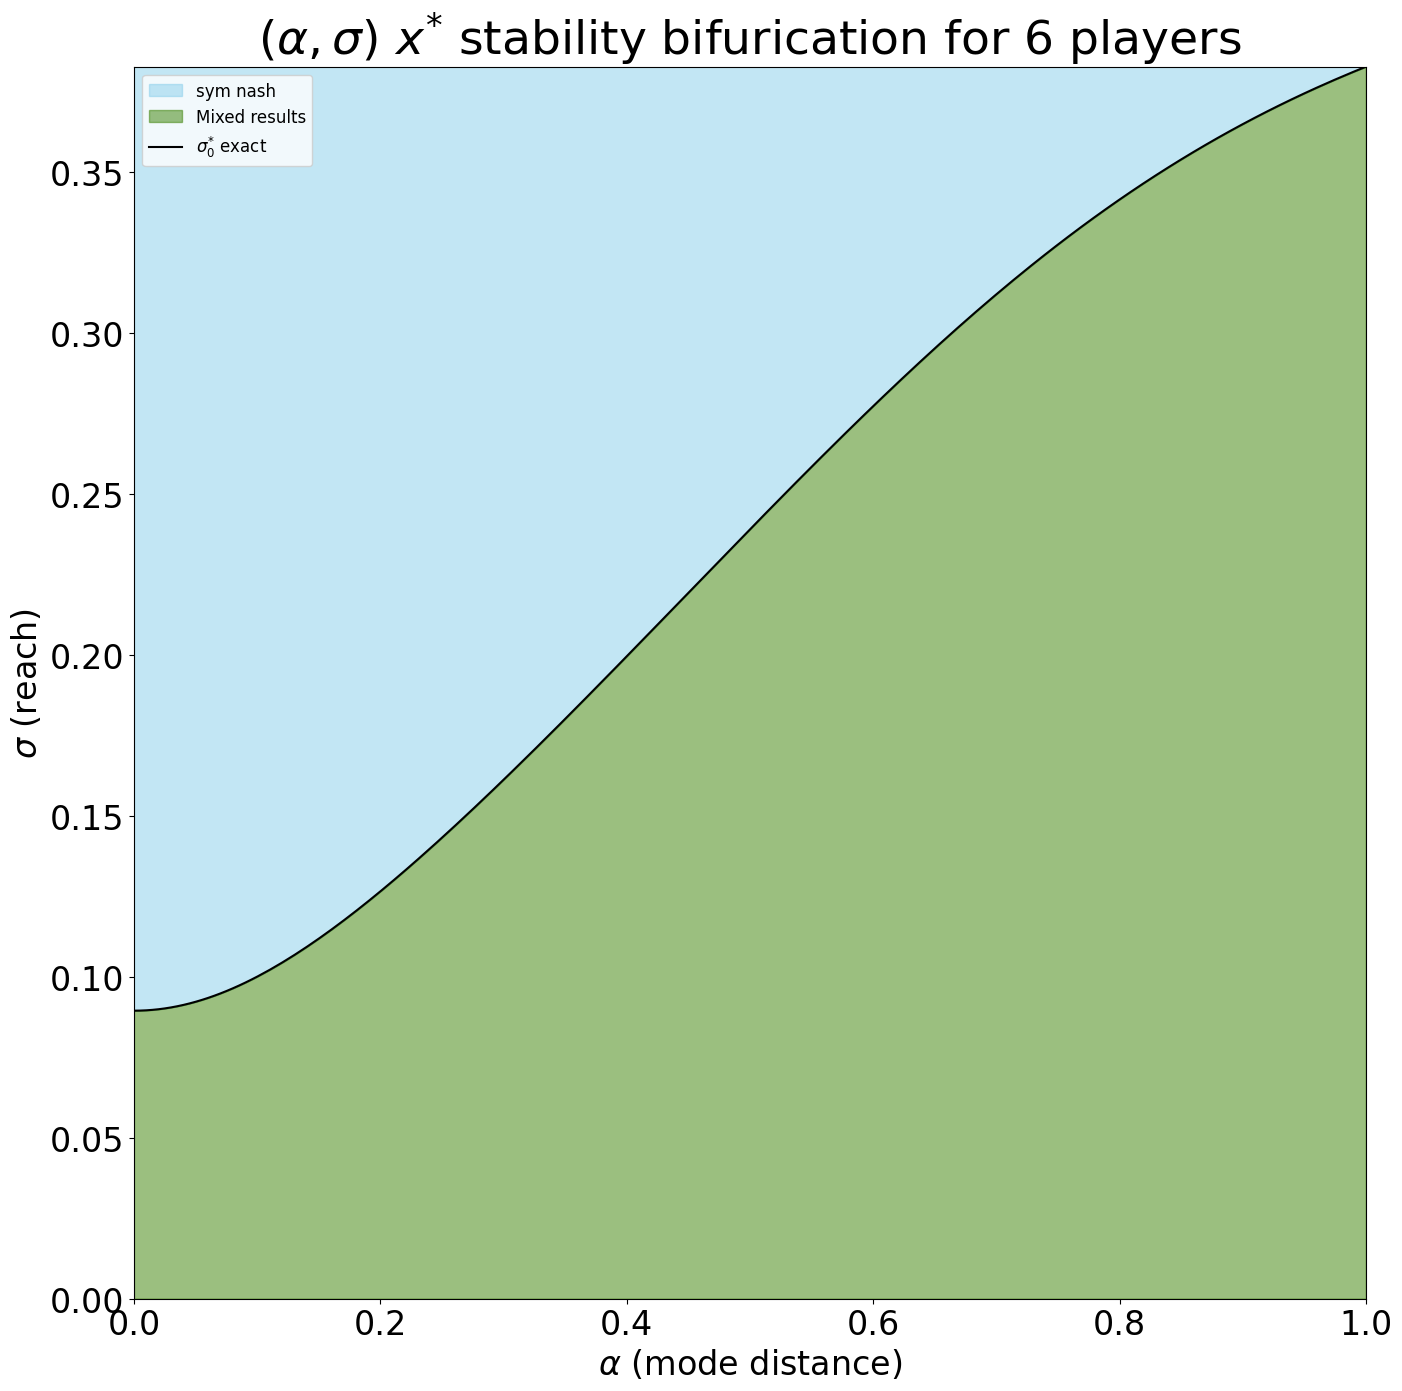

In [20]:
fig